In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from collections import Counter
import re
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import optuna
import xgboost as xgb
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score, f1_score, accuracy_score
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import LabelEncoder
import sklearn
from IPython.display import display

## LOAD

In [14]:
df = pd.read_csv('review_dana_labelled.csv')
pd.set_option('display.max_colwidth', None)
df.head()

,userName,score,at,content,sentimen
0,Elisya Kasni,5,2024-02-15 11:24:56,Bagus,POSITIVE
1,Rusman Man,2,2024-02-15 11:24:03,Dana mmg keren mantap.,POSITIVE
2,Qiliw Sadega,1,2024-02-15 11:23:34,Saya ngajuin upgrade dana premium krna ktp saya buram jdi ga bisa verifikasi..trus coba lewat email di suruh nunggu 3 hri .ini udh 3 hri lebih msih gitu² doang saldo sya d dana jdi ga bisa d apa²in.. gmna ini solusi nya,NEGATIVE
3,Kijutjrv2 Kijut,3,2024-02-15 11:22:46,Kocak mana diskon nya ml malah eror segala kaga ikhlas ngasih diskon nya,NEGATIVE
4,Fifi Alfiyah,1,2024-02-15 11:21:34,Saldo hilang karena no lama Hilang ganti no saldonya gk ada sama sekali dana tidak bertanggung jawab Buktinya saldo saya gk ada !!! Saldo lama saya 1800.000,NEGATIVE


In [15]:
df['character_length'] = df['content'].apply(lambda x: len(x))

## EDA

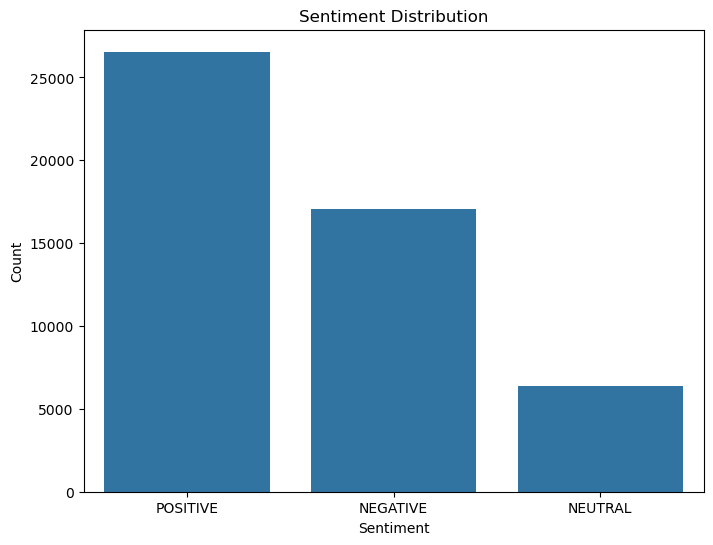

In [16]:
plt.figure(figsize=(8, 6))
sns.countplot(x = df['sentimen'])
plt.title('Sentiment Distribution')
plt.ylabel('Count')
plt.xlabel('Sentiment')
plt.show()

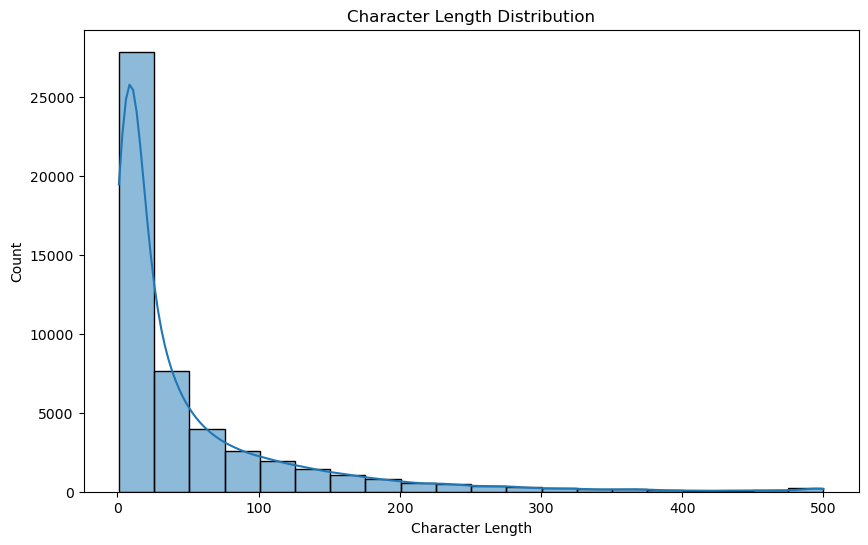

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(df['character_length'], bins=20, kde=True)
plt.title('Character Length Distribution')
plt.xlabel('Character Length')
plt.ylabel('Count')
plt.show()

## Split Data

In [ ]:
df_train, df_temp = train_test_split(df, test_size=0.2, random_state=42, stratify=df['sentimen'])
df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=42, stratify=df_temp['sentimen'])

In [ ]:
print("10 Contoh Teks Asli (Raw):")
print(df_train['content'].sample(10, random_state=42).tolist())

semua_teks = " ".join(df_train['content'].astype(str).tolist()).lower()
pecahan_kata = semua_teks.split()
frekuensi_kata = Counter(pecahan_kata)

print("\n30 Kata Paling Sering Muncul:")
print(frekuensi_kata.most_common(30))

kata_dengan_angka = [kata for kata in pecahan_kata if any(karakter.isdigit() for karakter in kata)]
frekuensi_angka = Counter(kata_dengan_angka)

print("\n20 Kata Mengandung Angka Paling Sering Muncul:")
print(frekuensi_angka.most_common(20))

10 Contoh Teks Asli (Raw):
['bagusss', 'Saya kasih pull deh', 'apk ini enak kali makenya apalagi Banyak diskonnya', "Kalau mau upgrade ke premium harus pake KTP, kalo KTP rusak atau tidak jelas ada opsi lainke pake SIM ke. Ini udah gitu butu pe'a ga bisa upgrade ke premium", 'bagis', 'Ga niat banget, ga ada CS, nyuruh robot yg muter-muter jawabnya', 'bagus bangetttttttttt', 'Tolong untuk devouler sistem jaringan nya kurang cepet,jadi kalo di buka agak leg', 'kurang puas', 'Mantap']

30 Kata Paling Sering Muncul:
[('dana', 10543), ('saya', 9091), ('di', 7876), ('sangat', 6879), ('bisa', 6010), ('tidak', 4541), ('bagus', 4458), ('aplikasi', 4059), ('dan', 3833), ('ada', 3805), ('nya', 3377), ('ini', 3112), ('ke', 3055), ('saldo', 2937), ('mantap', 2784), ('membantu', 2775), ('uang', 2451), ('gak', 2445), ('mau', 2444), ('akun', 2314), ('sudah', 2298), ('ga', 2278), ('transaksi', 2117), ('yg', 2007), ('yang', 1978), ('tapi', 1876), ('ok', 1860), ('masuk', 1843), ('baik', 1825), ('apk', 16

In [ ]:
kamus_slang = {
    'gak': 'tidak',
    'gk': 'tidak',
    'ga': 'tidak',
    'ngk': 'tidak',
    'nggak': 'tidak',
    'tpi': 'tapi',
    'yg': 'yang',
    'apk': 'aplikasi',
    'udah': 'sudah',
    'dgn': 'dengan',
    'bgt': 'banget',
    'tf': 'transfer',
    'wd': 'tarik',
    'cs': 'customer service',
    'abdet': 'update'
}

def clean_text_dana(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'<.*?>+', ' ', text)
    text = re.sub(r'([a-z]+)[2²]', r'\1 \1', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    
    kata_kata = text.split()
    kata_terjemahan = [kamus_slang.get(kata, kata) for kata in kata_kata]
    text = ' '.join(kata_terjemahan)
    
    return text.strip()

df_train['content_clean'] = df_train['content'].apply(clean_text_dana)
df_val['content_clean'] = df_val['content'].apply(clean_text_dana)
df_test['content_clean'] = df_test['content'].apply(clean_text_dana)

In [21]:
df_train.duplicated().sum()

np.int64(0)

In [22]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40000 entries, 20498 to 10395
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   userName          40000 non-null  object
 1   score             40000 non-null  int64 
 2   at                40000 non-null  object
 3   content           40000 non-null  object
 4   sentimen          40000 non-null  object
 5   character_length  40000 non-null  int64 
 6   content_clean     40000 non-null  object
dtypes: int64(2), object(5)
memory usage: 2.4+ MB


In [ ]:
STransformer = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

teks_latih = df_train['content_clean'].tolist()
teks_validasi = df_val['content_clean'].tolist()

x_train = STransformer.encode(teks_latih, show_progress_bar=True)
x_val = STransformer.encode(teks_validasi, show_progress_bar=True)

y_train = df_train['sentimen']
y_val = df_val['sentimen']

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/1250 [00:00<?, ?it/s]

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

## Base Model

In [ ]:
def evaluate_models(x_train, y_train, x_val, y_val):
    lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
    lr.fit(x_train, y_train)
    preds_lr = lr.predict(x_val)

    svm = SVC(class_weight='balanced', kernel='linear', random_state=42)
    svm.fit(x_train, y_train)
    preds_svm = svm.predict(x_val)
    
    rf = RandomForestClassifier(class_weight='balanced', random_state=42)
    rf.fit(x_train, y_train)
    preds_rf = rf.predict(x_val)
    
    print("Report Logistic Regression")
    print(classification_report(y_val, preds_lr))
    
    print("\nReport Support Vector Machine")
    print(classification_report(y_val, preds_svm))
    
    print("\nReport Random Forest")
    print(classification_report(y_val, preds_rf))

evaluate_models(x_train, y_train, x_val, y_val)

Report Logistic Regression
              precision    recall  f1-score   support

    NEGATIVE       0.78      0.75      0.77      1708
     NEUTRAL       0.49      0.76      0.59       637
    POSITIVE       0.94      0.84      0.89      2655

    accuracy                           0.80      5000
   macro avg       0.74      0.78      0.75      5000
weighted avg       0.83      0.80      0.81      5000


Report Support Vector Machine
              precision    recall  f1-score   support

    NEGATIVE       0.78      0.76      0.77      1708
     NEUTRAL       0.48      0.76      0.59       637
    POSITIVE       0.95      0.83      0.89      2655

    accuracy                           0.80      5000
   macro avg       0.74      0.78      0.75      5000
weighted avg       0.83      0.80      0.81      5000


Report Random Forest
              precision    recall  f1-score   support

    NEGATIVE       0.72      0.90      0.80      1708
     NEUTRAL       0.63      0.27      0.38      

## Optuna XGB

In [ ]:
sklearn.set_config(enable_metadata_routing=False)

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)

neg_idx = le.transform(['NEGATIVE'])[0]

class BalancedXGB(xgb.XGBClassifier):
    def __init__(self, faktor_negatif=1.0, **kwargs):
        self.faktor_negatif = faktor_negatif
        super().__init__(**kwargs)
        
    def fit(self, X, y, **kwargs):
        weights = compute_sample_weight('balanced', y)
        weights = np.where(y == neg_idx, weights * self.faktor_negatif, weights)
        kwargs['sample_weight'] = weights
        return super().fit(X, y, **kwargs)

def optimize_level_1(trial, model_name):
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    cv_scores = []
    
    for tr_idx, val_idx in cv.split(x_train, y_train_enc):
        X_tr, X_val = x_train[tr_idx], x_train[val_idx]
        y_tr, y_val_fold = y_train_enc[tr_idx], y_train_enc[val_idx]
        
        if model_name == 'XGBoost':
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 100, 200),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
                'max_depth': trial.suggest_int('max_depth', 3, 5),
                'reg_alpha': trial.suggest_float('reg_alpha', 0.1, 10.0, log=True),
                'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 10.0, log=True),
                'min_child_weight': trial.suggest_int('min_child_weight', 3, 10),
                'subsample': trial.suggest_float('subsample', 0.5, 0.8),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.8),
                'gamma': trial.suggest_float('gamma', 0.5, 3.0)
            }
            faktor_neg = trial.suggest_float('faktor_negatif', 1.0, 1.3)
            model = BalancedXGB(faktor_negatif=faktor_neg, **params, random_state=42, n_jobs=-1)
            model.fit(X_tr, y_tr)
            
        elif model_name == 'LogisticRegression':
            params = {
                'C': trial.suggest_float('C', 0.01, 10.0, log=True),
                'solver': trial.suggest_categorical('solver', ['lbfgs', 'newton-cg'])
            }
            model = LogisticRegression(**params, class_weight='balanced', max_iter=1000, random_state=42)
            model.fit(X_tr, y_tr)
            
        preds = model.predict(X_val)
        f1_mac = f1_score(y_val_fold, preds, average='macro')
        cv_scores.append(f1_mac)
        
    return np.mean(cv_scores)

models_to_tune = ['XGBoost', 'LogisticRegression']
best_l1_models = {}

for m_name in models_to_tune:
    study = optuna.create_study(direction='maximize')
    study.optimize(lambda trial: optimize_level_1(trial, m_name), n_trials=10)
    
    print(f"\n[Level 1] {m_name} Best Params: {study.best_params}")
    
    if m_name == 'XGBoost':
        best_params = study.best_params.copy()
        best_faktor = best_params.pop('faktor_negatif')
        final_model = BalancedXGB(faktor_negatif=best_faktor, **best_params, random_state=42, n_jobs=-1)
    elif m_name == 'LogisticRegression':
        final_model = LogisticRegression(**study.best_params, class_weight='balanced', max_iter=1000, random_state=42)
        
    best_l1_models[m_name] = final_model

[I 2026-09-15 09:08:01,760] A new study created in memory with name: no-name-aba79917-df5d-4cd1-aa94-dae292810cfb
d:\Anaconda\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:08:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "faktor_negatif" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\Anaconda\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:08:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "faktor_negatif" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\Anaconda\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:08:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "faktor_negatif" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[I 2026-09-15 09:08:36,191] Trial 0 finished with value: 0.735003665736124 and parameters: {'n_estimators': 136, 'learning_rate': 0.06765943805035447, 'max_depth':


[Level 1] XGBoost Best Params: {'n_estimators': 140, 'learning_rate': 0.08433277771004653, 'max_depth': 5, 'reg_alpha': 0.36403760863478685, 'reg_lambda': 4.181862304510092, 'min_child_weight': 4, 'subsample': 0.6659545274142418, 'colsample_bytree': 0.6401843543052306, 'gamma': 1.4088111910321317, 'faktor_negatif': 1.2820749942320466}


[I 2026-09-15 09:16:24,967] Trial 0 finished with value: 0.7350987125564653 and parameters: {'C': 0.1665538011262727, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.7350987125564653.
[I 2026-09-15 09:16:33,032] Trial 1 finished with value: 0.7350676025967049 and parameters: {'C': 0.15647852190432804, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.7350987125564653.
[I 2026-09-15 09:16:42,221] Trial 2 finished with value: 0.737075610821146 and parameters: {'C': 0.24690358168134766, 'solver': 'lbfgs'}. Best is trial 2 with value: 0.737075610821146.
[I 2026-09-15 09:16:48,399] Trial 3 finished with value: 0.7317686882428108 and parameters: {'C': 0.08276647617981374, 'solver': 'lbfgs'}. Best is trial 2 with value: 0.737075610821146.
[I 2026-09-15 09:16:59,063] Trial 4 finished with value: 0.7381683591038456 and parameters: {'C': 0.39670327877193107, 'solver': 'lbfgs'}. Best is trial 4 with value: 0.7381683591038456.
[I 2026-09-15 09:17:03,111] Trial 5 finished with value: 0.7245195767


[Level 1] LogisticRegression Best Params: {'C': 2.573558303863086, 'solver': 'lbfgs'}


In [ ]:
def optimize_level_2(trial):
    c_param = trial.suggest_float('C', 0.01, 10.0, log=True)
    meta_model = LogisticRegression(C=c_param, class_weight='balanced', max_iter=1000, random_state=42)
    
    cv_meta = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    stacking_clf = StackingClassifier(
        estimators=[
            ('xgb', best_l1_models['XGBoost']),
            ('logreg', best_l1_models['LogisticRegression'])
        ],
        final_estimator=meta_model,
        cv=cv_meta
    )
    
    meta_scores = []
    
    for tr_idx, val_idx in cv_meta.split(x_train, y_train_enc):
        X_tr_meta, X_val_meta = x_train[tr_idx], x_train[val_idx]
        y_tr_meta, y_val_meta = y_train_enc[tr_idx], y_train_enc[val_idx]
        
        stacking_clf.fit(X_tr_meta, y_tr_meta)
        preds_meta = stacking_clf.predict(X_val_meta)
        meta_scores.append(f1_score(y_val_meta, preds_meta, average='macro'))
        
    return np.mean(meta_scores)

study_meta = optuna.create_study(direction='maximize')
study_meta.optimize(optimize_level_2, n_trials=10)

[I 2026-09-15 09:17:54,909] A new study created in memory with name: no-name-76dad8a8-8663-4901-aaa3-02ff5e0e258f
d:\Anaconda\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:17:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "faktor_negatif" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\Anaconda\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:18:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "faktor_negatif" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\Anaconda\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:18:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "faktor_negatif" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\Anaconda\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:18:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { 

In [ ]:
meta_final = LogisticRegression(C=study_meta.best_params['C'], class_weight='balanced', max_iter=1000, random_state=42)
cv_final = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
final_model = StackingClassifier(
    estimators=[
        ('xgb', best_l1_models['XGBoost']),
        ('logreg', best_l1_models['LogisticRegression'])
    ],
    final_estimator=meta_final,
    cv=cv_final
)

final_model.fit(x_train, y_train_enc)

train_preds_enc = final_model.predict(x_train)
val_preds_enc = final_model.predict(x_val)

train_preds = le.inverse_transform(train_preds_enc)
val_preds = le.inverse_transform(val_preds_enc)

print("\n[Validation Report]")
print(classification_report(y_val, val_preds))

train_recalls = recall_score(y_train, train_preds, average=None)
val_recalls = recall_score(y_val, val_preds, average=None)

train_rec_neg = train_recalls[neg_idx]
val_rec_neg = val_recalls[neg_idx]
gap_recall = train_rec_neg - val_rec_neg

print(f"Recall Negative (Train) : {train_rec_neg:.4f}")
print(f"Recall Negative (Val): {val_rec_neg:.4f}")
print(f"Recall Gap: {gap_recall:.4f}")

if gap_recall > 0.05:
    print("Status: OVERFIT")
elif gap_recall < -0.02:
    print("Status: UNDERFIT")
else:
    print("Status: GOOD FIT")

raw_weights = np.abs(final_model.final_estimator_.coef_).mean(axis=0)
weight_pct = (raw_weights / np.sum(raw_weights)) * 100

print("\n[Base Models Weight Distribution]")
print(f"XGBoost: {weight_pct[0]:.2f}%")
print(f"LogReg: {weight_pct[1]:.2f}%")

d:\Anaconda\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:57:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "faktor_negatif" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\Anaconda\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:58:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "faktor_negatif" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\Anaconda\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:58:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "faktor_negatif" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\Anaconda\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:58:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "faktor_negatif" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\Anaconda\Lib\site-packages\xgboos


[Validation Report]
              precision    recall  f1-score   support

    NEGATIVE       0.81      0.76      0.79      1708
     NEUTRAL       0.49      0.77      0.60       637
    POSITIVE       0.95      0.85      0.90      2655

    accuracy                           0.81      5000
   macro avg       0.75      0.80      0.76      5000
weighted avg       0.84      0.81      0.82      5000

Recall Negative (Train) : 0.7927
Recall Negative (Val): 0.7646
Recall Gap: 0.0281
Status: GOOD FIT

[Base Models Weight Distribution]
XGBoost: 18.49%
LogReg: 14.85%


In [ ]:
test_texts = df_test['content_clean'].tolist()
X_test = STransformer.encode(test_texts, show_progress_bar=True)

test_preds_enc = final_model.predict(X_test)
test_preds = le.inverse_transform(test_preds_enc)
df_test['predicted_sentiment'] = test_preds

print("\n[Test Data Predictions (Top 5)]")
display(df_test[['content', 'predicted_sentiment']].head())

if 'sentimen' in df_test.columns:
    y_test_true = df_test['sentimen']
    
    print("\n[Test Report]")
    print(classification_report(y_test_true, test_preds))
    
    test_recalls = recall_score(y_test_true, test_preds, average=None)
    test_rec_neg = test_recalls[neg_idx]
    test_gap_recall = train_rec_neg - test_rec_neg 
    
    print(f"Recall Negative (Train): {train_rec_neg:.4f}")
    print(f"Recall Negative (Test): {test_rec_neg:.4f}")
    print(f"Recall Gap: {test_gap_recall:.4f}")
    
    if test_gap_recall > 0.05:
        print("Status: OVERFIT")
    elif test_gap_recall < -0.02:
        print("Status: UNDERFIT")
    else:
        print("Status: GOOD FIT")
else:
    print("\n[Notice] Target column 'sentimen' not found in test data. Evaluation skipped.")

Batches:   0%|          | 0/157 [00:00<?, ?it/s]


[Test Data Predictions (Top 5)]


,content,predicted_sentiment
25595,Alhamdulillah masih lancar,POSITIVE
6149,"Mohon dengan sangat kenapa aplikasi saya gbisa masuk terus dan harus vertikasi akun dana sedangkan dananya aja gbisa dibuka, dan kenapa harus kirim kode otp melalu SMS sedangkan nomor nyah udah non aktif",NEGATIVE
31780,"Ini apk gak jelas, Masah saldo bisa dibobol orang yg tak dikenal. Tolong direspon dulu udah 3 hari masah gak ada respon nya",NEGATIVE
29775,terus ditingkatkan lagi keamanannya 😊😊,POSITIVE
20425,bagus dan cepat,POSITIVE



[Test Report]
              precision    recall  f1-score   support

    NEGATIVE       0.80      0.74      0.77      1707
     NEUTRAL       0.48      0.76      0.59       637
    POSITIVE       0.94      0.86      0.90      2656

    accuracy                           0.81      5000
   macro avg       0.74      0.79      0.75      5000
weighted avg       0.84      0.81      0.82      5000

Recall Negative (Train): 0.7927
Recall Negative (Test): 0.7446
Recall Gap: 0.0481
Status: GOOD FIT
